# Homework 3: Table Manipulation and Visualization

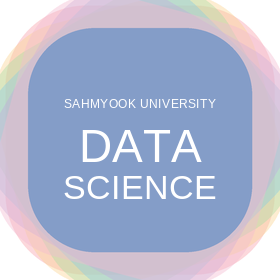

Please complete this notebook by filling in the cells provided. Before you begin, execute the previous cell to load the provided tests.

**Helpful Resource:**
- [Python Reference](http://data8.org/sp26/reference/): Cheat sheet of helpful array & table methods used in this data science course!

**Recommended Reading**: 
* [Visualization](https://inferentialthinking.com/chapters/07/Visualization.html)

For all problems that you must write explanations and sentences for, you **must** provide your answer in the designated space. Moreover, throughout this homework and all future ones, **please be sure to not re-assign variables throughout the notebook!** For example, if you use `max_temperature` in your answer to one question, do not reassign it later on. Otherwise, you will fail tests that you thought you were passing previously!

Directly sharing answers is not okay, but discussing problems with the course staff or with other students is encouraged.

You should start early so that you have time to get help if you're stuck.

In [ ]:
# Setup (run this first!)
!pip install -q otter-grader datascience
!git clone https://github.com/jihyungkim94/datascience.git 2>/dev/null || true
import os, json
os.chdir('/content/datascience/hw/hw03')
os.makedirs('tests', exist_ok=True)
with open('hw03.ipynb') as _f:
    _nb = json.load(_f)
for _name, _test in _nb['metadata']['otter']['tests'].items():
    with open('tests/' + _name + '.py', 'w') as _f:
        _f.write('OK_FORMAT = True\n\ntest = ' + repr(_test) + '\n')
import otter
grader = otter.Notebook('hw03.ipynb')
print('Ready! (14 tests loaded)')

---

The point breakdown for this assignment is given in the table below:
| Category | Points |
| --- | --- |
| Autograder (Coding questions) | 87 |
| Manual (Visualization questions) | 13 |
| **Total** | 100 |


In [ ]:
# Don't change this cell; just run it. 

import numpy as np
from datascience import *
import warnings
warnings.simplefilter('ignore', FutureWarning)

# These lines do some fancy plotting magic.\n",
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 1. Birth Rates

The following table gives Census-based population estimates for each US state on both July 1, 2015 and July 1, 2016. The last four columns describe the components of the estimated change in population during this time interval. **For all questions below, assume that the word "states" refers to all 52 rows including Puerto Rico and the District of Columbia.**

The data was taken from [the U.S. Census data](http://www2.census.gov/programs-surveys/popest/datasets/2010-2016/national/totals/nst-est2016-alldata.csv). (Note: If the file doesn't download for you when you click the link, you can copy and paste the link address it into your address bar!) If you want to read more about the different column descriptions, click [in the Census column descriptions](http://www2.census.gov/programs-surveys/popest/datasets/2010-2015/national/totals/nst-est2015-alldata.pdf).

The raw data is a bit messy—run the cell below to clean the table and make it easier to work with.

In [ ]:
# Don't change this cell; just run it.
pop = Table.read_table('nst-est2016-alldata.csv').where('SUMLEV', 40).select([1, 4, 12, 13, 27, 34, 62, 69])
pop = pop.relabeled('POPESTIMATE2015', 'START_POP').relabeled('POPESTIMATE2016', 'END_POP')
pop = pop.relabeled('BIRTHS2016', 'BIRTHS').relabeled('DEATHS2016', 'DEATHS')
pop = pop.relabeled('NETMIG2016', 'MIGRATION').relabeled('RESIDUAL2016', 'OTHER')
pop = pop.with_columns("REGION", np.array([int(region) if region != "X" else 0 for region in pop.column("REGION")]))
pop.set_format([2, 3, 4, 5, 6, 7], NumberFormatter(decimals=0)).show(5)

---

**Question 1.1.** Assign `us_birth_rate` to the total US annual birth rate during this time interval. The annual birth rate for a year-long period is the total number of births in that period as a proportion of the total population size at the start of the time period. **(7 Points)**

_Hint:_ What does each row in the `pop` table represent? How can we use this to find the total US population?


In [ ]:
us_birth_rate = ...
us_birth_rate

In [ ]:
grader.check("q1_1")

---

**Question 1.2.** Assign `movers` to the number of states for which the **absolute value** of the **annual rate of migration** was higher than 1%. The annual rate of migration for a year-long period is the net number of migrations (in minus out) as a proportion of the population size at the start of the period. The `MIGRATION` column contains estimated annual net migration counts by state. **(7 Points)**

*Hint*: `migration_rates` should be a table and `movers` should be a number.


In [ ]:
migration_rates = ...
movers = ...
movers

In [ ]:
grader.check("q1_2")

---

**Question 1.3.** Assign `west_births` to the total number of births that occurred in region 4 (the Western US). **(7 Points)**

*Hint:* Make sure you double check the type of the values in the `REGION` column and appropriately filter (i.e. the types must match!).


In [ ]:
west_births = ...
west_births

In [ ]:
grader.check("q1_3")

---

**Question 1.4.** In the next question, you will be creating a visualization to understand the relationship between birth and death rates. The annual death rate for a year-long period is the total number of deaths in that period as a proportion of the population size at the start of the time period.

What visualization is most appropriate to see if there is an association between annual birth and death rates across multiple states in the United States?

1. Line Graph
2. Bar Chart
3. Scatter Plot

Assign `visualization` below to the number corresponding to the correct visualization. **(6 Points)**


In [ ]:
visualization = ...

In [ ]:
grader.check("q1_4")

<!-- BEGIN QUESTION -->

--- 

**Question 1.5.** In the code cell below, create a visualization that will help us determine if there is an association between birth rate and death rate during this time interval. It may be helpful to create an intermediate table containing the birth and death rates for each state. **(5 Points)**

Things to consider:

- What type of chart will help us illustrate an association between 2 variables?
- How can you manipulate a certain table to help generate your chart?
- Check out the [the textbook's Visualization chapter](https://inferentialthinking.com/chapters/07/Visualization.html) for this homework!

**Note: All plotting and visualization questions in this homework will be manually graded on correctness. Even though these questions do not have a grader check cell, they will still count towards your score!**

In [ ]:
# In this cell, use birth_rates and death_rates to generate your visualization
birth_rates = pop.column('BIRTHS') / pop.column('START_POP')
death_rates = pop.column('DEATHS') / pop.column('START_POP')
...

<!-- END QUESTION -->

---

**Question 1.6.** True or False: There is an association between birth rate and death rate during this time interval. 

Assign `assoc` to `True` or `False` in the cell below. **(7 Points)**


In [ ]:
assoc = ...

In [ ]:
grader.check("q1_6")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 2. Uber

**Note:** We recommend reading [Chapter 7.2](https://inferentialthinking.com/chapters/07/2/Visualizing_Numerical_Distributions.html) of the textbook before starting on Question 3.

Below we load tables containing 200,000 weekday Uber rides in the Manila, Philippines, and Boston, Massachusetts metropolitan areas from the [Uber Movement](https://www.uber.com/newsroom/introducing-uber-movement-2/) project. The `sourceid` and `dstid` columns contain codes corresponding to start and end locations of each ride. The `hod` column contains codes corresponding to the hour of the day the ride took place. The `ride time` column contains the length of the ride in minutes.

In [ ]:
boston = Table.read_table("boston.csv")
manila = Table.read_table("manila.csv")
print("Boston Table")
boston.show(4)
print("Manila Table")
manila.show(4)

<!-- BEGIN QUESTION -->

--- 

**Question 2.1.** Produce a histogram that visualizes the distributions of all ride times in Boston using the given bins in `equal_bins`. **(4 Points)**

*Hint:* See [Chapter 7.2](https://inferentialthinking.com/chapters/07/2/Visualizing_Numerical_Distributions.html) if you're stuck on how to specify bins.

**Note: All plotting and visualization questions in this homework will be manually graded on correctness. Even though these questions do not have a grader check cell, they will still count towards your score!**

In [ ]:
equal_bins = np.arange(0, 120, 5)
...

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

---

**Question 2.2.** Now, produce a histogram that visualizes the distribution of all ride times in Manila using the given bins. **(4 Points)**


In [ ]:
equal_bins = np.arange(0, 120, 5)
...

# Don't delete the following line!
plt.ylim(0, 0.05);

<!-- END QUESTION -->

---

**Question 2.3.** Let's take a closer look at the y-axis label. Assign `unit_meaning` to an integer (1, 2, 3) that corresponds to the "unit" in "Percent per unit". **(7 Points)**

1. minute  
2. ride time  
3. second


In [ ]:
unit_meaning = ...
unit_meaning

In [ ]:
grader.check("q2_3")

---

**Question 2.4.** Assign `boston_under_15` and `manila_under_15` to the percentage of rides that are less than 15 minutes in their respective metropolitan areas. Use the height variables provided below in order to compute the percentages. Your solution should only use height variables, numbers, and mathematical operations. You should **not** access the tables `boston` and `manila` in any way. **(8 Points)**

> ***Note:*** that the height variables (i.e. `boston_under_5`) represent the height of the bin it describes.


In [ ]:
boston_under_5_bin_height = 1.2
manila_under_5_bin_height = 0.6
boston_5_to_under_10_bin_height = 3.2
manila_5_to_under_10_bin_height = 1.4
boston_10_to_under_15_bin_height = 4.9
manila_10_to_under_15_bin_height = 2.2

boston_under_15 = ...
manila_under_15 = ...

boston_under_15, manila_under_15

In [ ]:
grader.check("q2_4")

---

**Question 2.5.** Let's take a closer look at the distribution of ride times in Boston. Assign `boston_median_bin` to an integer (1, 2, 3, or 4) that corresponds to the bin that contains the median time. **(6 Points)**

1. 0-8 minutes  
2. 8-14 minutes  
3. 14-20 minutes  
4. 20-40 minutes  

*Hint:* The median of a sorted list has half of the list elements to its left, and half to its right.


In [ ]:
boston_median_bin = ...
boston_median_bin

In [ ]:
grader.check("q2_5")

---

**Question 2.6.** Identify the main differences between the two histograms, in terms of the statistical properties.

Assign all correct statements to the array `histogram_answer` (e.g. `histogram_answer = make_array(1,2,3)`).
> *Hint*: Without performing any calculations, what can you observe about the average or skew of each histogram? A distribution has a right skew if it has a long right “tail” of values. **(4 Points)**

1. Manila had a higher average ride time than Boston.
2. Boston had a higher average ride time than Manila.
3. The Manila histogram was more right skewed than the Boston histogram.
3. The Boston histogram was more right skewed than the Manila histogram.


In [ ]:
histogram_answer = ...

In [ ]:
grader.check("q2_6")

--- 

**Question 2.7.** Boston is known to have very cold winters, while Manila is known for having heavy traffic. These factors might help to explain the differences you observed in Question 2.6. 

Assign all statements that would support our observations about Boston and Manila ride times to the array `difference_factors`. **(4 Points)**

1. Boston’s colder weather encourages people to substitute walking with short rides, leading to shorter ride times on average.
2. Boston’s colder weather results in weather-related delays, leading to longer ride times on average.
3. Manila's heavy traffic encourages people to avoid traveling long distances, leading to shorter ride times on average.
4. Manila's heavy traffic causes frequent delays, leading to longer ride times on average.


In [ ]:
difference_factors = ...

In [ ]:
grader.check("q2_7")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 3. Histograms

Consider the following scatter plot: 

![Alt text](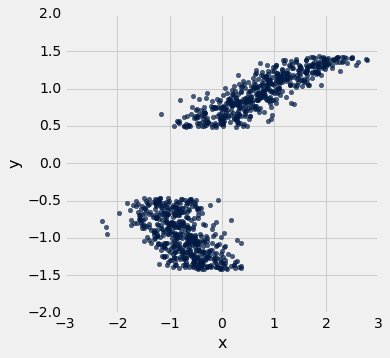 "Scatter plot showing data points for the variables 'x' and 'y'. The data are symmetric about the x-axis centered at 0 and symmetric about the y-axis centered at 0, but with no data in the [-0.5, 0.5] range on the y-axis.")

The axes of the plot represent values of two variables: $x$ and $y$. 

Suppose we have a table called `t` that has two columns in it:

- `x`: a column containing the x-values of the points in the scatter plot
- `y`: a column containing the y-values of the points in the scatter plot

Below, you are given three histograms—one corresponds to column `x`, one corresponds to column `y`, and one does not correspond to either column. 

**Histogram A:**
 
![Alt text](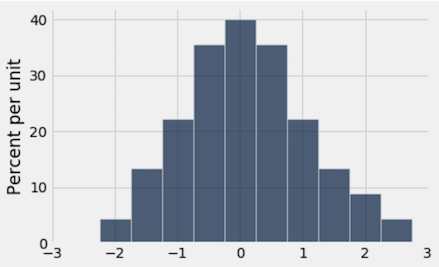 "Symmetrical, bell-shaped histogram centered around 0")

**Histogram B:**

![Alt text](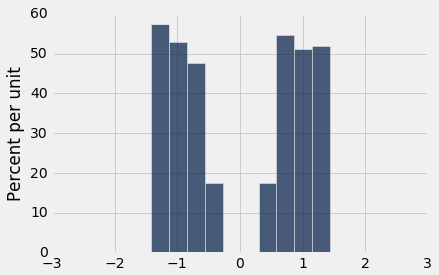 "Symmetrical histogram with two peaks at -1 and 1 but no data around 0")

**Histogram C:**

![Alt text](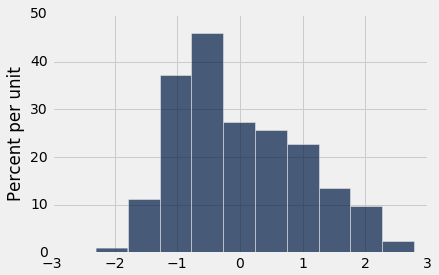 "Asymmetrical histogram with a peak around -0.5 and a right skew")

---

**Question 3.1.** Suppose we run `t.hist('x')`. Which histogram does this code produce? Assign `histogram_column_x` to either 1, 2, or 3. **(7 Points)**

1. Histogram A
2. Histogram B
3. Histogram C


In [ ]:
histogram_column_x = ...

In [ ]:
grader.check("q3_1")

---

**Question 3.2.** Select all valid reasons why you chose the histogram from Question 1, and assign your answers to the array `histogram_reasoning_x`. **(5 Points)**

1. Since the scatter plot shows two roughly symmetric clusters to the left and right of 0 (on the $x$-axis), the histogram for $x$ should be approximately symmetric around 0.
2. Because there are no signficiant gaps in the values of the $x$-variable, we would expect the histogram for $x$ to have no gaps in it.
3. Since the scatter plot shows two distinct clusters, the histogram of $x$ should have two peaks with an empty gap between them.
4. The values of the $x$-variable range from approximately -2 to 3, so the histogram must also have a range of values from approximately -2 to 3.
5. Because the two clusters on the scatter plot overlap in the area between -1 and 0, we would expect the bins to be taller around the -1 to 0 area of the histogram, since each vertical slice in this range contains more points.


In [ ]:
histogram_reasoning_x = ...

In [ ]:
grader.check("q3_2")

---

**Question 3.3.** Suppose we run `t.hist('y')`. Which histogram does this code produce? Assign `histogram_column_y` to either 1, 2, or 3. **(7 Points)**

1. Histogram A
2. Histogram B
3. Histogram C


In [ ]:
histogram_column_y = ...

In [ ]:
grader.check("q3_3")

---

**Question 3.4.** Select all valid reasons why you chose the histogram from Question 3, and assign your answers to the array `histogram_reasoning_y` **(5 Points)**

1. Since the scatter plot shows two roughly symmetric clusters to the left and right of 0 (on the $y$-axis), the histogram for $y$ should be approximately symmetric around 0.
2. The values of the $y$-variable range from approximately -1.5 to 1.5, so the histogram must also have a range of values from approximately -1.5 to 1.5.
3. Since the scatter plot shows two distinct clusters, the histogram of $y$ should have two peaks with an empty gap between them.
4. There is a are no gaps in the points in the $y$-direction, so we would not expect a gap in the histogram of those values.
5. Because the two masses on the scatter plot overlap in the area between -1 and 0, we would expect the bins to be taller around the -1 to 0 area of the histogram, since each vertical slice in this range contains more points.


In [ ]:
histogram_reasoning_y = ...

In [ ]:
grader.check("q3_4")

---

You're done with Homework 3!  

**Important submission steps:**
1. Run all the cells and verify that every test passes.
2. Choose **File → Download → Download .ipynb**.
3. Upload the `.ipynb` file to the LMS.

**Make sure every cell has been run before you download — the outputs are part of what you hand in.**


## Pets of this data science course

Ash, Scout, and Jules thinks you deserve a restful nap after completing this assignment!

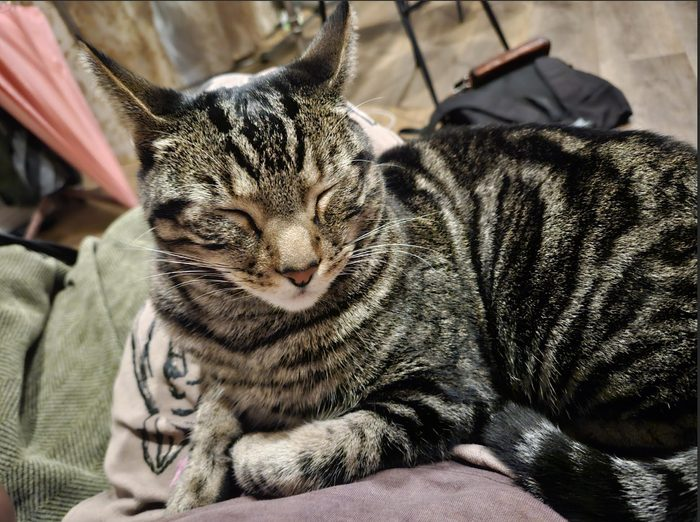
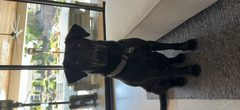
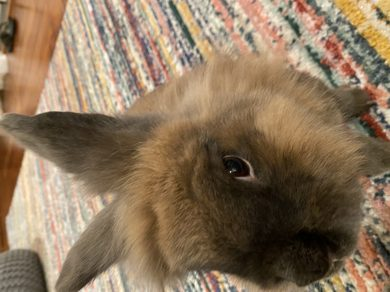

Congrats on finishing Homework 3!

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [ ]:
grader.check_all()

### Submission
1. Run `grader.check_all()` above and make sure all tests pass.
2. **File → Download → Download .ipynb**
3. Upload the `.ipynb` file to the LMS.

_(`grader.export()` does not work on Google Colab, so it has been removed.)_